# Module 1: Clustering

This notebook contains the preparation of the final dataset (`dataset_0.csv`) for the clustering algorithms, as well as the clustering itself.

## 1) Load Packages + Data

In [2]:
#load packages
import pandas as pd 
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import prince
import geopandas as gpd
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from collections import defaultdict

In [3]:
#load data
df = pd.read_csv("../../data/final_datasets/dataset_0.csv", dtype={"plr_id": str})
df.head(3)

,plr_id,plr_name,bez,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,01100101,Stülerstraße,01 - Mitte,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,01100102,Großer Tiergarten,01 - Mitte,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,01100103,Lützowstraße,01 - Mitte,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [4]:
df.shape

(527, 45)

In [5]:
#define id columns and feature columns
id_cols = ["plr_id", "plr_name", "bez"]
feat_cols = [c for c in df.columns if c not in id_cols]

## 2) Imputation

There are still two PLR's with missing columns. These will be imputed using **K-Nearest Neighbors (KNN) imputation**. Each sample’s missing values are imputed using the mean value from n_neighbors nearest neighbors. Two samples are close if the features that neither is missing are close. More info can be found in the sklearn documentation (https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html).

In [6]:
# per-PLR list of missing columns (most readable)
mask = df[feat_cols].isna().any(axis=1)
for _, r in df.loc[mask].iterrows():
    missing = [c for c in feat_cols if pd.isna(r[c])]
    print(f"{r['plr_id']} — {r['plr_name']}: {', '.join(missing)}")

07200412 — Schöneberger Linse: re_brw_niveau, re_brw_trend
11300723 — Bornitzstraße: re_miete_trend


In [7]:
# keep plr_id retrievable; work on a feature-only matrix
X = df[feat_cols].copy()
ids = df[id_cols].copy()

# 1) impute the 3 gaps (2 PLRs) from similar PLRs
X_imp = pd.DataFrame(
    KNNImputer(n_neighbors=3).fit_transform(X),
    columns=feat_cols, index=df.index,
)

# sanity checks
print(len(feat_cols), "Features |", X_imp.shape, "| verbleibende NaN:", int(X_imp.isna().sum().sum()))

42 Features | (527, 42) | verbleibende NaN: 0


In [8]:
X_imp.columns

Index(['re_miete_niveau', 're_miete_trend', 're_leerstandsquote',
       're_brw_niveau', 're_brw_trend', 're_dichte_all',
       'soc_young_to_middle_adult_share_2025',
       'soc_young_to_middle_adult_share_change_2021_2025',
       'soc_single_person_hh_share_change_2021_2024',
       'soc_average_household_size_2024',
       'soc_average_household_size_change_2021_2024',
       'soc_households_without_minor_children_share_change_2021_2024',
       'soc_internal_migration_volume_rate_2025',
       'soc_internal_migration_volume_rate_change_2021_2025',
       'soc_internal_net_migration_rate_2025',
       'soc_internal_net_migration_rate_change_2021_2025',
       'soc_unemployment_share_change_2020_2024',
       'soc_transfer_benefit_share_2024',
       'soc_transfer_benefit_share_change_2020_2024',
       'soc_single_parent_household_share_2024',
       'soc_single_parent_household_share_change_2021_2024',
       'com_median_age_level_2026', 'com_share_solo_level_2026',
       'com

## 3) Scaling: Yeo-Johnson Transformer

We know from prior eda and data prep in the `notebooks/data_prep/dataprep.ipynb` that more than half of the features are skewed and that there are positive and negative values. This means that StandardScaler (which leaves skew intact) and plain log (can't take negatives) won't work here. As an alternative, the Yeo-Johnson transformer will be used. Developed by I.K. Yeo and R.A. Johnson in 2000, this transformation is part of the power transformation family, similar to Box-Cox, but it extends its applicability to data containing non-positive values. The goal remains the same: to stabilize variance, reduce skewness, and make the data distribution more closely resemble a normal (Gaussian) distribution. The important concept is that the transformation provides a continuous function across zero and handles positive, zero, and negative values consistently to achieve symmetry. Documentation for the implementation in scikit-learn can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html. 

In [9]:
X_imp.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,22.7,2.142,3.050847,3890.584913,-0.326098,10.653753,0.460,0.000,-0.004,1.60,...,0.001367,-0.000276,0.024083,0.002754,0.003153,-0.002800,0.001395,13.000000,0.118160,0.102663
1,20.3,1.059,4.557180,3440.019389,-0.426678,24.075666,0.479,0.003,-0.010,1.77,...,0.003015,0.001063,0.028592,0.002506,0.004856,-0.000930,-0.000664,129.333333,0.228719,0.297506
2,23.0,1.356,1.863997,3541.826020,-0.440097,16.223680,0.455,0.022,0.006,1.70,...,0.001498,0.001101,0.032530,-0.001222,0.000177,-0.001019,0.000103,43.833333,0.323783,0.130135


In [10]:
X_scaled = pd.DataFrame(
    PowerTransformer("yeo-johnson", standardize=True).fit_transform(X_imp),
    columns=feat_cols, index=X_imp.index,
)

X_scaled.head(3)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773
2,1.767611,0.419433,0.074113,1.329091,-1.175228,1.284139,0.736851,0.555171,-0.191582,-0.444817,...,-0.021163,0.706418,2.197820,-0.451547,-0.201956,-0.461120,-1.439860,0.830252,0.755869,0.929094


## 4) Handling Dimension Imbalance

In [11]:
re  = sum(c.startswith("re_")  for c in feat_cols)
soc = sum(c.startswith("soc_") for c in feat_cols)
com = sum(c.startswith("com_") for c in feat_cols)
print(f"{len(feat_cols)} variables (real estate {re}, social {soc}, commercial {com})")

42 variables (real estate 8, social 15, commercial 19)


The dimensions (real-estate, social, commercial) currently have a different number of variables, which is a problem during clustering because a larger dimension in size would currently contribute more to the distance-based clustering. There are two options to deal with this: 

**1) Block Weighting:** Multiplying each feature by 1/√(number of features in its block), so all three dimensions contribute equally regardless of how many columns they have. Because Euclidean distance sums squared differences, a block of k standardised features contributes ≈ k to the distance, and to scale that contribution down to 1, each feature is multiplied by a weight w whose square cancels the k — i.e. w² = 1/k, so w = 1/√k.

**2) MFA (balance + reduction + redundancy in one step):** MFA runs a PCA on each dimension separately, divides each block by the strength of its first principal component, then runs one global PCA on the combined, balanced blocks so that the clustering happens on the resulting components. This fixes block imbalance and absorbs within-block redundancy at the same time. However, interpretability becomes two-step (read component loadings, then cluster profiles) and thus more complex. 


We will start with block weighting — it's transparent, keeps the variables, and directly fixes the one real problem (imbalance).

### Block Weighting

In [12]:
# assign each feature to its dimension
def block_of(col):
    if col.startswith("re_"):  return "re"
    if col.startswith("soc_"): return "soc"
    return "com"

feat_cols = X_scaled.columns
block_sizes = pd.Series([block_of(c) for c in feat_cols]).value_counts()

# weight = 1 / sqrt(block size), so each dimension contributes equally
weights = pd.Series({c: 1 / np.sqrt(block_sizes[block_of(c)]) for c in feat_cols})

# apply to the standardized matrix
X_weighted = X_scaled * weights

# check: each block's total squared contribution should be equal
for b in block_sizes.index:
    cols = [c for c in feat_cols if block_of(c) == b]
    print(f"{b:4s} ({len(cols)} vars, w={1/np.sqrt(block_sizes[b]):.3f}): "
          f"contribution = {(X_weighted[cols]**2).sum().sum():.1f}")

com  (19 vars, w=0.229): contribution = 527.0
soc  (15 vars, w=0.258): contribution = 527.0
re   (8 vars, w=0.354): contribution = 527.0


In [13]:
X_weighted.head(2)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,0.603730,0.475617,0.375645,0.495370,-0.181783,0.331834,0.203787,-0.109273,-0.220685,-0.305574,...,-0.013550,-0.052117,0.35146,0.218429,0.220156,-0.262305,-0.167046,-0.072099,-0.079653,0.225850
1,0.431118,0.011896,0.629719,0.461773,-0.387535,0.565343,0.254557,-0.073026,-0.315931,-0.001221,...,0.093422,0.156211,0.43553,0.197345,0.395622,-0.097422,-0.425418,0.431417,0.134762,0.628538


In [14]:
#for comparison:
X_scaled.head(2)

,re_miete_niveau,re_miete_trend,re_leerstandsquote,re_brw_niveau,re_brw_trend,re_dichte_all,soc_young_to_middle_adult_share_2025,soc_young_to_middle_adult_share_change_2021_2025,soc_single_person_hh_share_change_2021_2024,soc_average_household_size_2024,...,com_share_min_30y_slope,com_share_min_40y_slope,com_share_solo_slope,com_share_10plus_slope,com_gastro_share_slope,com_entry_rate_slope,com_exit_rate_slope,com_n_gastro,re_altbau_share,re_neubau_share
0,1.707607,1.345248,1.062483,1.401119,-0.514159,0.938569,0.789265,-0.423212,-0.854709,-1.183481,...,-0.059062,-0.227172,1.531979,0.952109,0.959637,-1.143363,-0.728138,-0.314274,-0.225292,0.638800
1,1.219387,0.033646,1.781115,1.306092,-1.096115,1.599031,0.985896,-0.282827,-1.223596,-0.004727,...,0.407217,0.680906,1.898433,0.860206,1.724478,-0.424651,-1.854356,1.880504,0.381165,1.777773


The weighting worked, the features became smaller because they were multiplied by their weights. As a result, each dimension now contributes equally.

### MFA (Multi Factor Analysis)

Multiple Factor Analysis (MFA) balances variable groups so that no dimension dominates simply by having more variables — it runs a separate PCA per group and normalizes each by its first singular value, unlike a plain PCA where our 19-variable commercial block would outweigh the 9-variable real-estate block. We cluster on the leading MFA components, which capture the structure common to all three dimensions.

The steps here follow the descriptions outlined in the repo by Max Halford for the prince package (https://maxhalford.github.io/prince/mfa/#resources).

In [15]:
#Since prince requires a MultiIndex, the first step is to create that.

def block_of(c):
    if c.startswith("re_"):  return "real_estate"
    if c.startswith("soc_"): return "social"
    return "commercial"

X_mfa = X_imp.copy()   # only imputed as base, MFA standardizes 
X_mfa.columns = pd.MultiIndex.from_tuples([(block_of(c), c) for c in X_mfa.columns])

#check
isinstance(X_mfa.columns, pd.MultiIndex)

True

In [16]:
# The groups are specified by the groups argument when calling fit.
groups = X_mfa.columns.levels[0].tolist()
groups

['commercial', 'real_estate', 'social']

In [17]:
#Next, the MFA is fit
mfa_3 = prince.MFA(
    n_components=3,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=0
)
mfa_3 = mfa_3.fit(
    X_mfa,
    groups=groups,
    supplementary_groups=None
)

In [18]:
#As with PCA, eigenvalues indicate how much variance (inertia) each component captures. 
# The first component represents the direction of maximum consensus across all groups.
mfa_3.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.885,16.10%,16.10%
1,1.446,12.35%,28.44%
2,0.979,8.35%,36.80%


Reaching 80% requires 18 components, 90% is only reached using 25 components. This flat spread shows the PLRs have no dominant low-dimensional structure — typical of a continuum, not separated clusters. 

Row coordinates position each PLR in the space defined by the MFA components. PLRs with similar profiles across all three dimensions will be close together.

It is visible here, that the first three components together capture only 36.8% of the variance. Let's look at a few more components to see how much is needed to capture 80-90% of the variance.


In [19]:
#Next, the mfa_25 is fit
mfa_25 = prince.MFA(
    n_components=25,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=0
)
mfa_25 = mfa_25.fit(
    X_mfa,
    groups=groups,
    supplementary_groups=None
)

mfa_25.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.885,16.10%,16.10%
1,1.446,12.35%,28.44%
2,0.979,8.35%,36.80%
3,0.669,5.71%,42.51%
4,0.614,5.24%,47.75%
5,0.570,4.87%,52.62%
6,0.419,3.57%,56.19%
7,0.391,3.34%,59.54%
8,0.349,2.98%,62.51%


In [20]:
X_mfa_coords_25 = mfa_25.row_coordinates(X_mfa)
print(X_mfa_coords_25.shape)

(527, 25)



With the goal in mind that we want our components to capture the variance that _seperates_ the PLR, a closer look at the table is warranted. Components 6-17 only capture 1-3% variance each, which is most likely an artefact of specific PLRs and not a shared structure of all dimensions. For clustering this is a problem: including these axes adds small random differences to every distance calculation, blurring rather than sharpening the groups. The first step before clustering is therefore to find the number of components that retains the shared structure without adding this noise. 

## 5) K-Means Clustering

### Weighted Dataset

#### Determining cluster size

As a starting point, we need to determine the best number of clusters. First, the Elbow Method will be used.

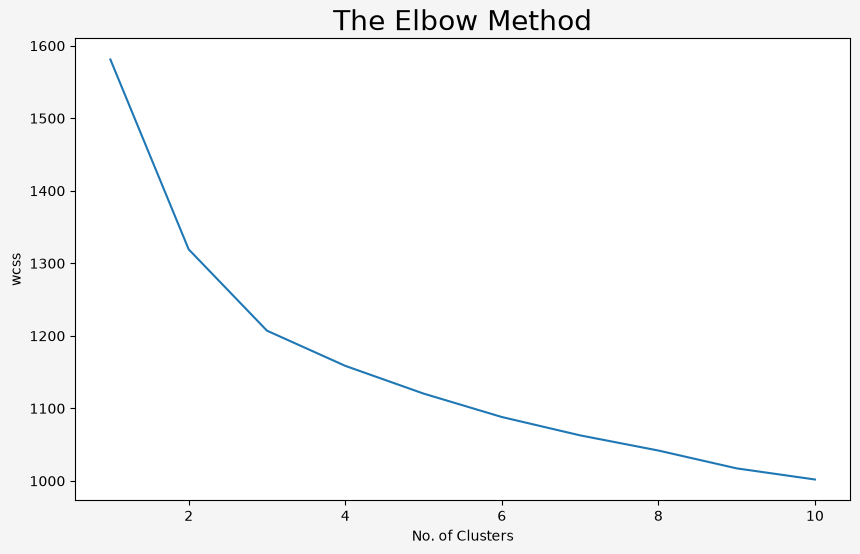

In [21]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(X_weighted)
    wcss.append(km.inertia_)
fig=plt.figure(figsize=(10,6))  
fig.patch.set_facecolor('#f6f5f5')

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

Based on the elbow, two or three clusters seem to be the most appropriate choice for our dataset, as the line starts to flatten out after that. Another method to estimate a good value for k is to have a look at the corresponding silhouette plots (https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html). Let's create silhouette plots for different numbers of k from 2 to 7.

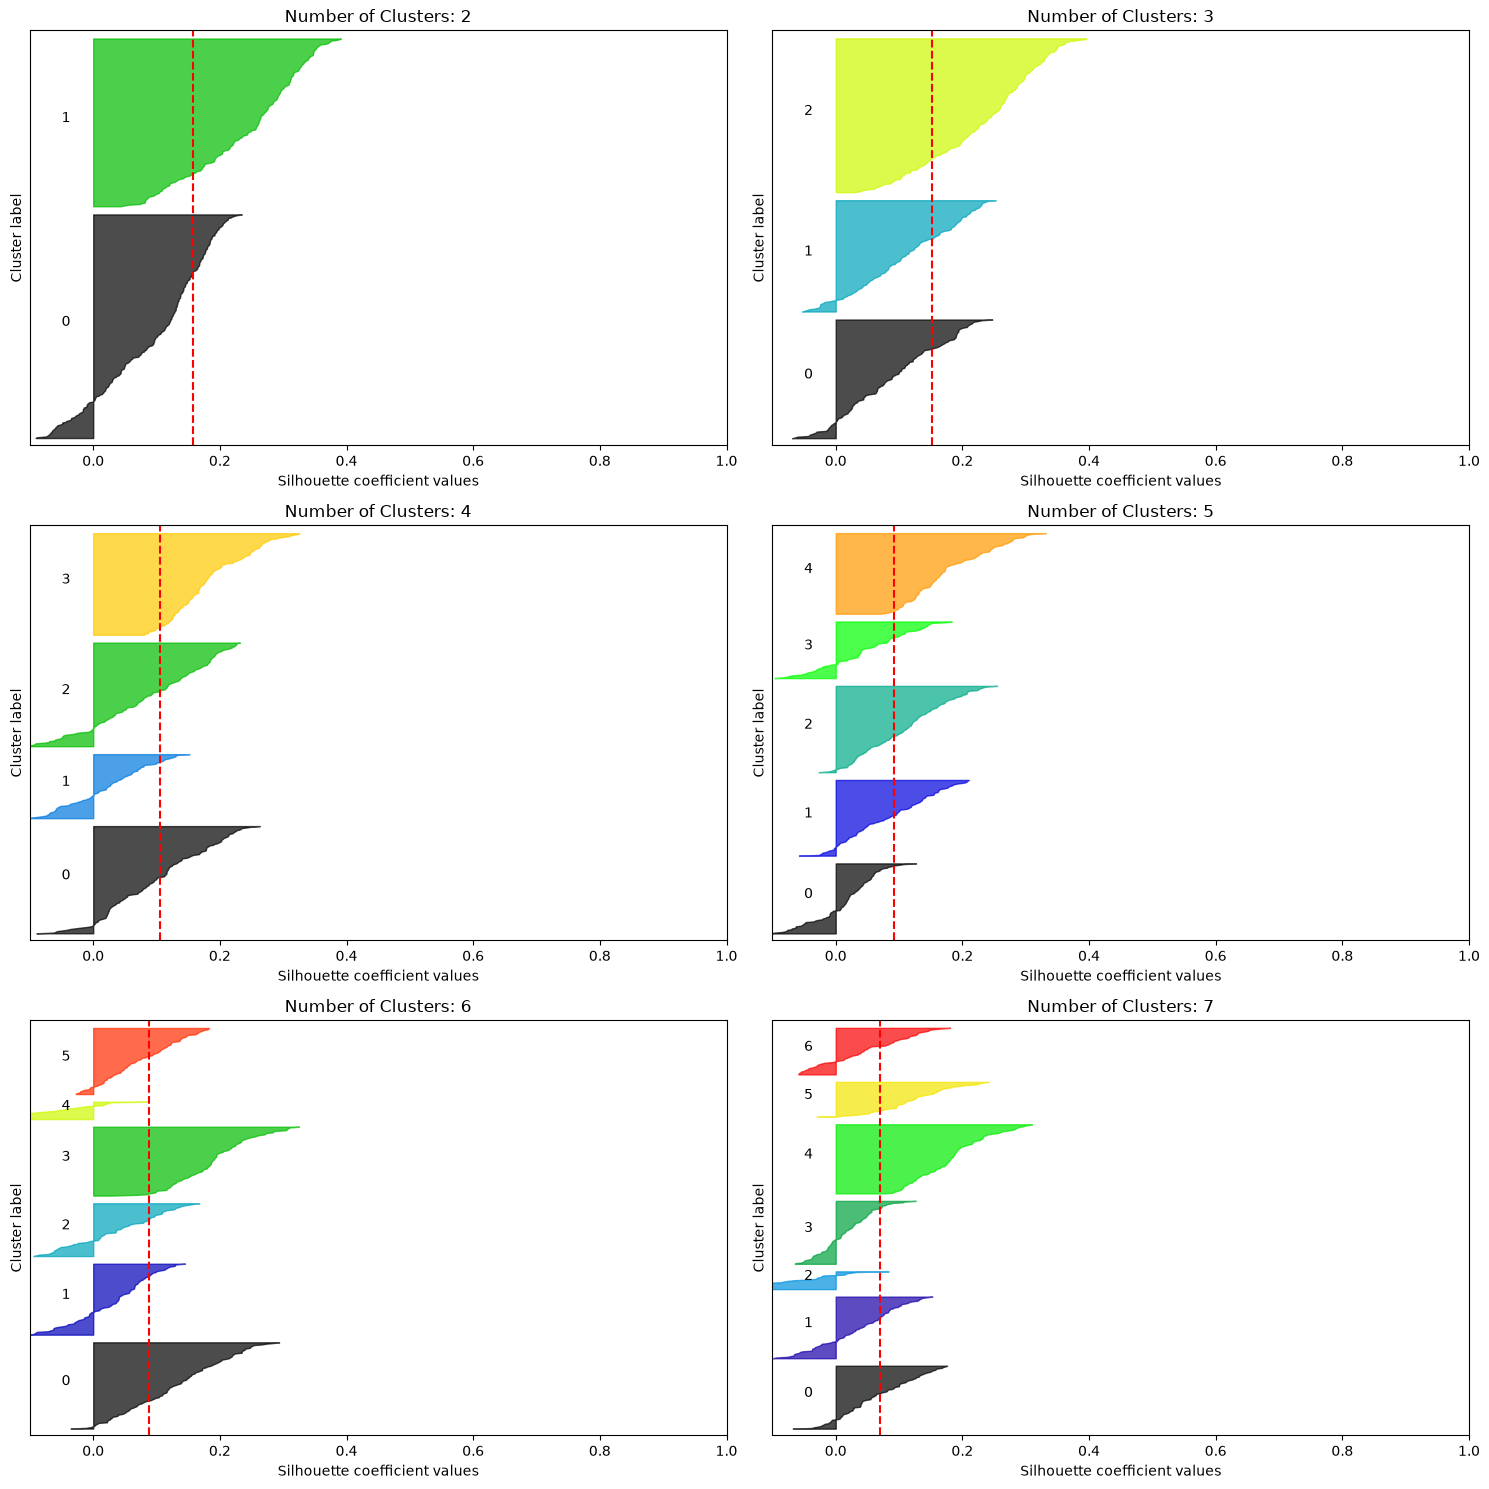

In [22]:
# Range of k values
range_n_clusters = range(2, 8)

# Create a figure to hold the subplots
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for k_idx, n_clusters in enumerate(range_n_clusters):
    ax = axes[k_idx]

    # Create a subplot for each k value
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_weighted) + (n_clusters + 1) * 10])

    # Initialize the KMeans algorithm
    kmeans = KMeans(n_clusters = n_clusters, init = 'k-means++', max_iter = 300, n_init = 50, random_state = 0)
    cluster_labels = kmeans.fit_predict(X_weighted)

    # Compute the silhouette scores for each sample
    silhouette_avg = silhouette_score(X_weighted, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_weighted, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f'Number of Clusters: {n_clusters}')
    ax.set_xlabel("Silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

**Silhouette analysis**

- Average scores are low across all k (~0.16 at k=2, ~0.15 at k=3, declining after). This is expected: the PLR form a socioeconomic continuum, not separated clusters, so every k shows points below the average and some negatives. The score can't prove an optimal k here — only rule out poor ones.
- It clearly points to k = 2 or 3: both have the highest scores and healthy cluster shapes (no cluster mostly below zero, balanced widths). k ≥ 5 breaks down — clusters appear almost entirely below zero and sizes fluctuate widely, the classic sign of over-partitioning.
- k = 3 is chosen over k = 2 because the score gap (0.15 vs 0.16) is negligible, k = 2 is too coarse for gentrification.
- k = 4 is a cluster size to keep in mind IF it helps to meaningfully divide the PLRs 

#### Clustering: k = 3

In [23]:
k = 3
km = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=0)
labels = km.fit_predict(X_weighted)

# put labels back on df
df = df.copy()
df["cluster_bw"] = labels
print(df["cluster_bw"].value_counts().sort_index())

cluster_bw
0    163
1    153
2    211
Name: count, dtype: int64


##### Plot Clustered PLRs:

In [24]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_bw"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("gematcht:", gdf["cluster_bw"].notna().sum(), "von", len(gdf))

gematcht: 527 von 542


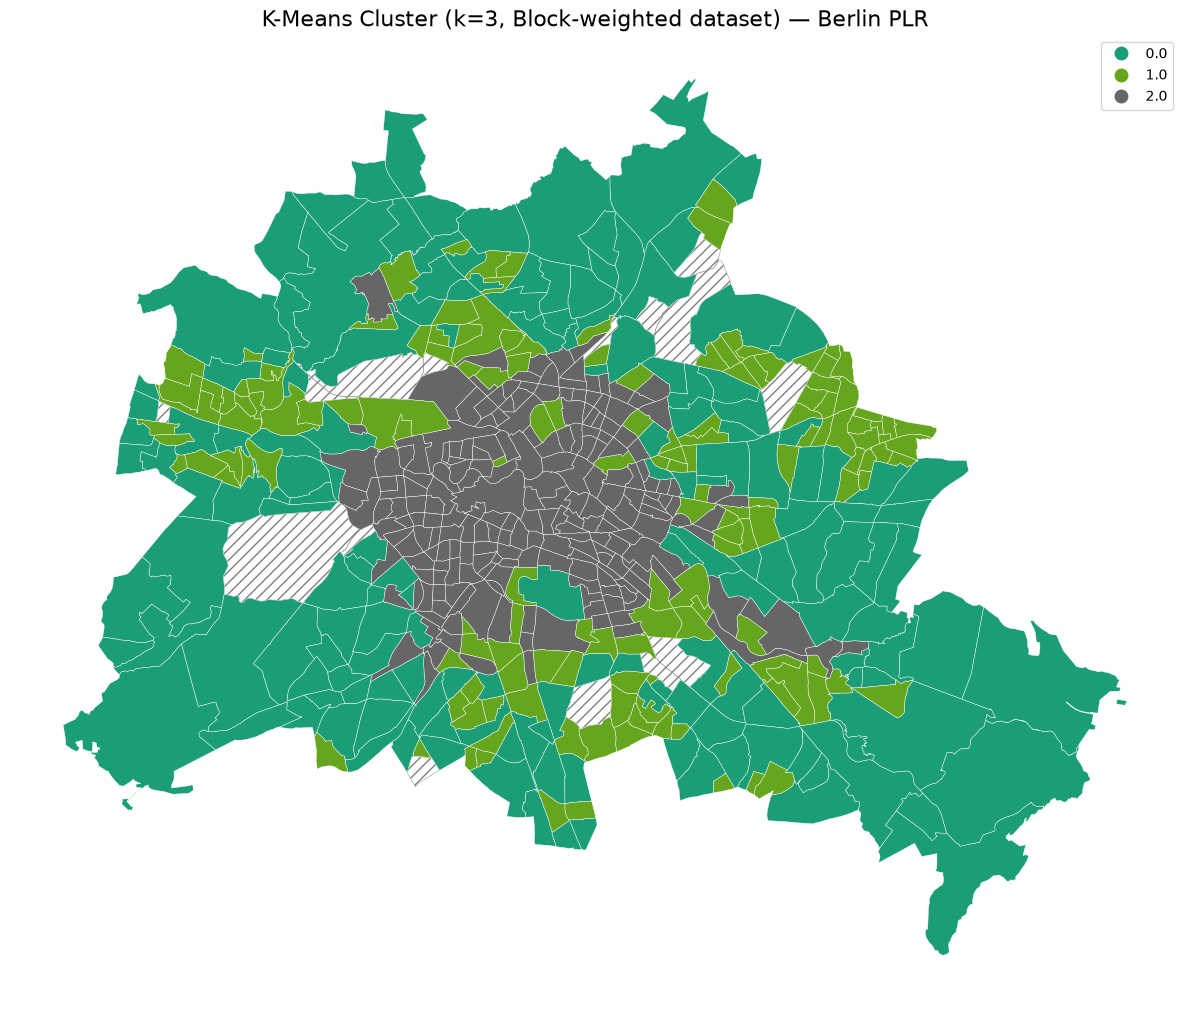

In [25]:
fig, ax = plt.subplots(figsize=(12, 12))

# mark missing PLR's
gdf[gdf["cluster_bw"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster_bw"].notna()].plot(
    column="cluster_bw", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

ax.set_title(f"K-Means Cluster (k={k}, Block-weighted dataset) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

The three clusters are geographically clearly separated, which is a strong sign that they capture a real spatial structure rather than statistical noise — the inner-city core, the peripheral ring, and the transition belt between them each form coherent contiguous areas that match Berlin's known centre-periphery geography. Whether the transition belt indicates active upgrading is a question for the cluster profiles. 

#### Clustering: k = 4

In [26]:
k = 4
km = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=0)
labels = km.fit_predict(X_weighted)

# put labels back on df
df = df.copy()
df["cluster_bw_4"] = labels
print(df["cluster_bw_4"].value_counts().sort_index())

cluster_bw_4
0    150
1     90
2    145
3    142
Name: count, dtype: int64


In [27]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_bw_4"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("gematcht:", gdf["cluster_bw_4"].notna().sum(), "von", len(gdf))

gematcht: 527 von 542


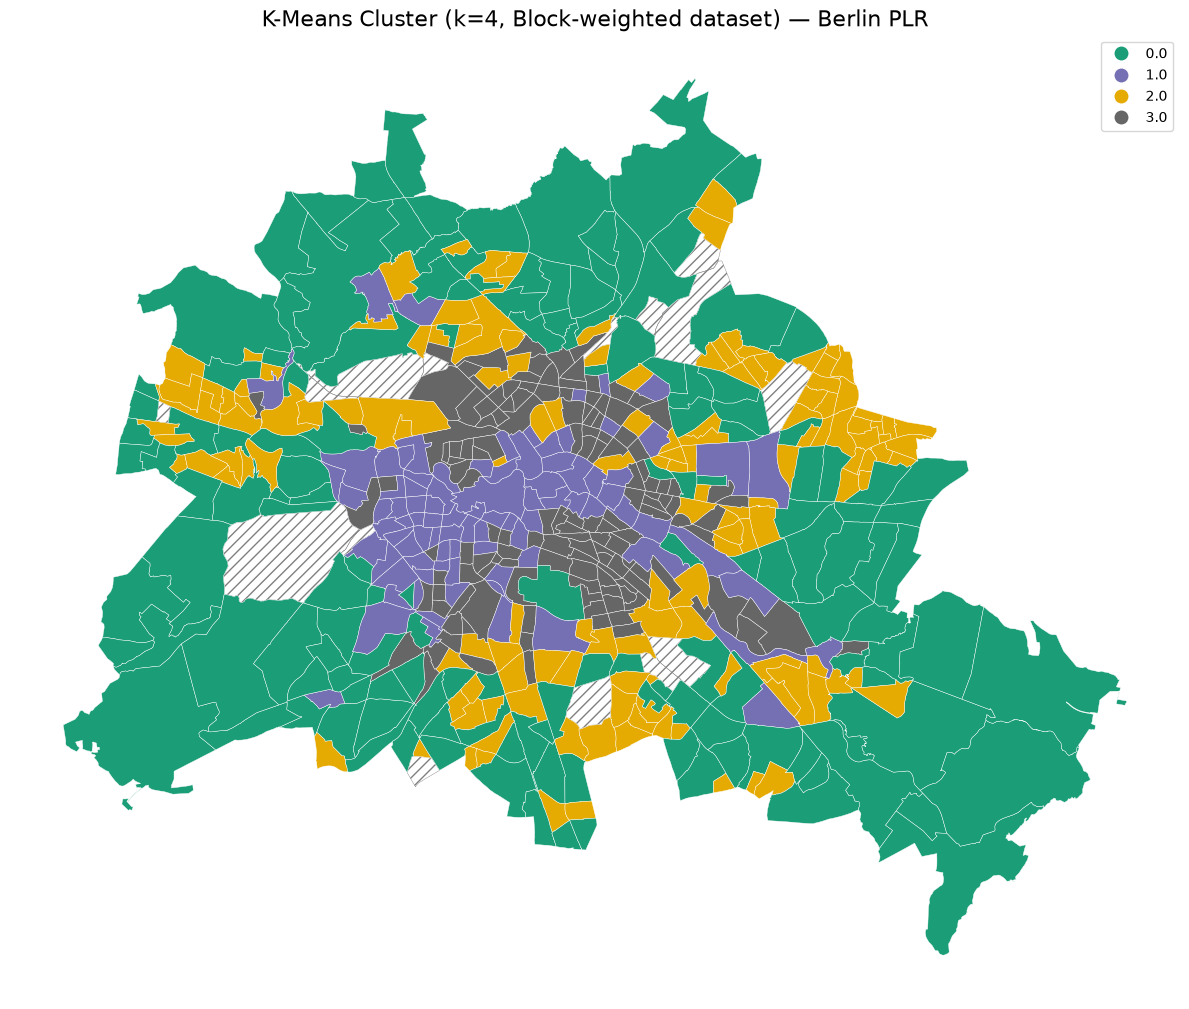

In [28]:
fig, ax = plt.subplots(figsize=(12, 12))

# mark missing PLR's
gdf[gdf["cluster_bw_4"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster_bw_4"].notna()].plot(
    column="cluster_bw_4", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

ax.set_title(f"K-Means Cluster (k={k}, Block-weighted dataset) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

It looks like moving from 3 to 4 clusters splits up the inner city cluster (prior cluster 2 on the map) into two clusters (cluster 1 and 3 on the map). This needs to be verified.

In [29]:
# crosstab: rows = k=3, columns = k=4
ct = pd.crosstab(df["cluster_bw"], df["cluster_bw_4"],
                 rownames=["k=3"], colnames=["k=4"], margins=True)
print(ct.to_string())

k=4    0   1    2    3  All
k=3                        
0    150  12    1    0  163
1      0   1  144    8  153
2      0  77    0  134  211
All  150  90  145  142  527


**How the fourth cluster forms (crosstab, k=3 rows × k=4 columns):**
- k=3 clusters 0 and 1 stay intact. Cluster 0 keeps 150/163 in one k=4 group; cluster 1 keeps 144/153. Adding a fourth cluster leaves these two (nearly) untouched.
The fourth cluster comes entirely from splitting the core (k=3 cluster 2). Its 211 PLRs divide cleanly into two k=4 groups: 77 and 134. Periphery and mid-ring are unaffected.
- So k=4 doesn't reshuffle the whole map — it makes exactly one targeted split, dividing the dense inner core into two types, while the outer clusters remain stable. Let's look more into what characterizes the newly formed clusters 1 and 3. 

In [30]:
# classify: dynamic = anything with trend/slope/change, else level
def is_dynamic(c):
    return any(t in c for t in ["_trend", "_slope", "_change"])

levels  = [c for c in feat_cols if not is_dynamic(c)]
dynamics = [c for c in feat_cols if is_dynamic(c)]

# keep dimension order (re, soc, com) within each group
def dim_order(cols):
    return ([c for c in cols if c.startswith("re_")]
            + [c for c in cols if c.startswith("soc_")]
            + [c for c in cols if c.startswith("com_")])

for label, cols in [("LEVEL (state)", dim_order(levels)),
                    ("DYNAMIC (trend / change)", dim_order(dynamics))]:
    comp = (df[df["cluster_bw_4"].isin([1, 3])]
            .groupby("cluster_bw_4")[cols].mean().T.round(2))
    comp.columns = ["cluster1", "cluster3"]
    comp["diff (1−3)"] = (comp["cluster1"] - comp["cluster3"]).round(2)
    print(f"\n{'='*75}\n{label}\n{'='*75}")
    print(comp.to_string())


LEVEL (state)
                                         cluster1  cluster3  diff (1−3)
re_miete_niveau                             20.23     16.43        3.80
re_leerstandsquote                           2.33      2.03        0.30
re_brw_niveau                             3338.03   2436.18      901.85
re_dichte_all                               13.05     12.13        0.92
re_altbau_share                              0.32      0.50       -0.18
re_neubau_share                              0.13      0.05        0.08
soc_young_to_middle_adult_share_2025         0.43      0.47       -0.04
soc_average_household_size_2024              1.72      1.67        0.05
soc_internal_migration_volume_rate_2025      0.19      0.17        0.02
soc_internal_net_migration_rate_2025         0.00     -0.01        0.01
soc_transfer_benefit_share_2024              0.08      0.12       -0.04
soc_single_parent_household_share_2024       0.04      0.04        0.00
com_median_age_level_2026                    6.96

The fourth cluster splits the dense inner core into a higher-value, more upscale, newer-build type (cluster 1) and a lower-value, older-building, higher-transfer type (cluster 3). This split is driven almost entirely by level variables — above all real estate (BRW 3338 vs. 2436) — while the dynamic variables barely differ (rent trends and social/commercial change are near-identical across the two). The fourth cluster therefore distinguishes two states of the inner city rather than a distinct upgrading process.

### MFA Dataset

#### Determining the optimal number of k and m

The starting point, again, is to find the optimal number of clusters. Recall from before that in addition, the optimum number of components for clustering needs to be determined. We want to find the "sweet spot" that captures just enough variance to separate the PLRs into meaningful clusters without capturing too much noise.

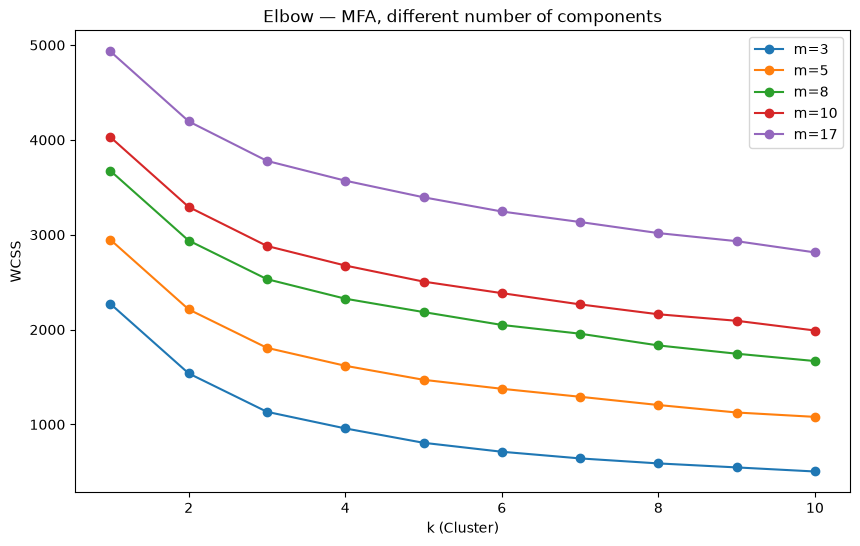

In [31]:
#First, let's use the Elbow method again, plotting the optimal k for different values of m
Ks = range(1, 11)
m_values = [3, 5, 8, 10, 17]

plt.figure(figsize=(10, 6))
for m in m_values:
    Xc = X_mfa_coords_25.iloc[:, :m] #dataset created above 
    wcss = []
    for k in Ks:
        km = KMeans(n_clusters=k, n_init=10, random_state=0)
        km.fit(Xc)
        wcss.append(km.inertia_)
    plt.plot(Ks, wcss, "o-", label=f"m={m}")

plt.xlabel("k (Cluster)")
plt.ylabel("WCSS")
plt.title("Elbow — MFA, different number of components")
plt.legend()
plt.show()

All five curves show the same elbow at k=2/3, regardless of m — so the choice of k is robust to the number of components. What's still open is m — the elbow varies k, not m, so it can't decide the number of components. 

A possibility is using the Adjusted Rand Index (ARI) score (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html), which is a number from ~0 to 1 that tells you how much two clusterings agree (in our case: whether the same PLRs are put into the same groups | 0 = agreement chance level; 1 = identical clusters). 

This ARI can be used to evaluate the resampling stability of the clusters. This will be done for different numbers of m, so we can pick the number that results in the highest ARI score. 

In [32]:
#define a function to test subsampling stability for 3 clusters 
def subsample_stability(X, k=3, n_runs=30, frac=0.8, random_state=0): #30 runs, each with 80% of the data 
    """
    Mean ARI between the full clustering and clusterings on 80% subsamples.
    High ARI = clusters are robust to which PLRs are included.
    """
    rng = np.random.RandomState(random_state)
    Xv = X.values if hasattr(X, "values") else X

    # reference clustering on all rows
    base = KMeans(k, n_init=10, random_state=0).fit_predict(Xv)

    aris = []
    for _ in range(n_runs):
        idx = rng.choice(len(Xv), int(frac * len(Xv)), replace=False)
        sub = KMeans(k, n_init=10, random_state=0).fit_predict(Xv[idx])
        # compare on the shared rows only
        aris.append(adjusted_rand_score(base[idx], sub))
    return np.mean(aris), np.std(aris)


## look at the ARI for 3 clusters using different m 
for m in [3, 4, 5, 6, 8, 10, 17, 25]:
    mean, sd = subsample_stability(X_mfa_coords.iloc[:, :m], k=3)
    print(f"m={m:2d}: mean ARI = {mean:.3f} (±{sd:.3f})")

NameError: name 'X_mfa_coords' is not defined

Cluster stability is high and nearly flat across all component counts (ARI 0.95–0.99), decreasing only marginally as more components are added. Since stability alone does not sharply favour any m, let's look at the captured variance again: 

In [ ]:
mfa_25.eigenvalues_summary.head(10)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,1.885,16.10%,16.10%
1,1.446,12.35%,28.44%
2,0.979,8.35%,36.80%
3,0.669,5.71%,42.51%
4,0.614,5.24%,47.75%
5,0.570,4.87%,52.62%
6,0.419,3.57%,56.19%
7,0.391,3.34%,59.54%
8,0.349,2.98%,62.51%


With 5 components, > 50% of the variance will be captured while also preserving near-maximum stability (mean ARI = 0.975). With a higher number of components, each component captures less than 4% of additional variance in the data, which is basically noise. 

In [ ]:
#let's run the MFA again with 5 components 
mfa_5 = prince.MFA(
    n_components=5,
    n_iter=3,
    rescale_with_mean=True,
    rescale_with_std=True,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=0
)
mfa_5 = mfa_5.fit(
    X_mfa,
    groups=groups,
    supplementary_groups=None
)

#Let's look at the transformed dataset. 
X_mfa_5_coords = mfa_5.row_coordinates(X_mfa)
X_mfa_5_coords.head(3)

component,0,1,2,3,4
0,1.782645,1.499999,1.126869,0.795095,-0.075589
1,2.692456,1.459528,0.400174,0.320553,0.610851
2,1.909189,0.638935,0.466569,0.443600,1.009705


In [ ]:
# individual contributions to the components 
mfa_5.group_contributions_.style.format('{:.0%}')

component,0,1,2,3,4
group,,,,,
commercial,22%,44%,10%,26%,53%
real_estate,47%,13%,3%,18%,2%
social,31%,43%,87%,55%,46%


In [ ]:
# Look at contribution of each dimension to the components
print(mfa_5.group_contributions_.sum(axis=1))   

# or weighted with own variance
ev = mfa_5.eigenvalues_
weighted = (mfa_5.group_contributions_ * ev).sum(axis=1) / ev.sum()
print("____________"*3)
print("Weighted contribution per dimension:")
print((weighted / weighted.sum() * 100).round(1))

group
commercial     1.548207
real_estate    0.836137
social         2.615656
dtype: float64
____________________________________
Weighted contribution per dimension:
group
commercial     29.5
real_estate    22.2
social         48.3
dtype: float64


The real estate dimension contributes less than the other two dimensions across 5 components. Let's check whether thus stays constant for more components.

In [ ]:
gc = mfa_25.group_contributions_          # rows = groups, columns = components
ev = np.asarray(mfa_25.eigenvalues_)      # eigenvalue per component

def weighted_contrib(n):
    """Variance-weighted total contribution of each group over the first n components."""
    g = gc.iloc[:, :n].values
    e = ev[:n]
    w = (g * e).sum(axis=1) / e.sum()
    return pd.Series(w / w.sum() * 100, index=gc.index)

# comparison table for 5, 10, 25 components
comparison = pd.DataFrame({
    f"m={n}": weighted_contrib(n) for n in [5, 10, 25]
}).round(1)

print("Variance-weighted contribution per dimension (%):")
print(comparison)

Variance-weighted contribution per dimension (%):
              m=5  m=10  m=25
group                        
commercial   29.5  29.2  37.0
real_estate  22.2  23.5  21.1
social       48.3  47.3  42.0


Contributions per dimension to Clusters: 
- Real estate stays at ~21–24% throughout — whether 5, 10, or 25 components. Real estate expresses its (limited) structure early and adds little afterward. Consistently low, consistent across all slices.
- Social dominates throughout (~42–48%), while commercial only catches up with more components (29% at m=5/10 → 37% at m=25). The core message holds: social + commercial together carry ~78–79%, real estate only ~21% — across all component counts.

So the dimensions do not contribute equally — not even across a nearly full decomposition. MFA gives equal starting chances, but real estate structurally contributes less. In order to find out why, we need to look at the inter-correlation within each dimension:

In [ ]:
# average |inter-correlation| within each block
for name in ["re", "soc", "com"]:
    cols = [c for c in feat_cols if c.startswith(name + "_")]
    corr = X_scaled[cols].corr(method = "spearman").abs()
    mean_r = corr.values[np.triu_indices(len(cols), k=1)].mean()
    print(f"{name}: mean |r| within block = {mean_r:.3f}  ({len(cols)} variables)")

re: mean |r| within block = 0.336  (8 variables)
soc: mean |r| within block = 0.198  (15 variables)
com: mean |r| within block = 0.183  (19 variables)


The variables within the real estate dimension are more correlated than the others. However, despite its higher coherence, it contributes less across components. MFA divides each block by its first singular value, so a tightly bundled block (high internal correlation → one dominant axis) gets scaled down more strongly. Real estate is therefore handled early precisely because of its compactness, and contributes little across the remaining components.

Considering that real estate is a very important dimension, this has to be kept in mind going forward. 

#### Clustering: k = 3

Now that the MFA components has been set to 5, we can start clustering. 

In [ ]:
k = 3
km = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=0)
labels = km.fit_predict(X_mfa_5_coords)

# put labels back
df = df.copy()
df["cluster_mfa"] = labels
print(df["cluster_mfa"].value_counts().sort_index())

cluster_mfa
0    175
1    170
2    182
Name: count, dtype: int64


##### Plot Clustered PLRs 

In [ ]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_mfa"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("gematcht:", gdf["cluster_mfa"].notna().sum(), "von", len(gdf))

gematcht: 527 von 542


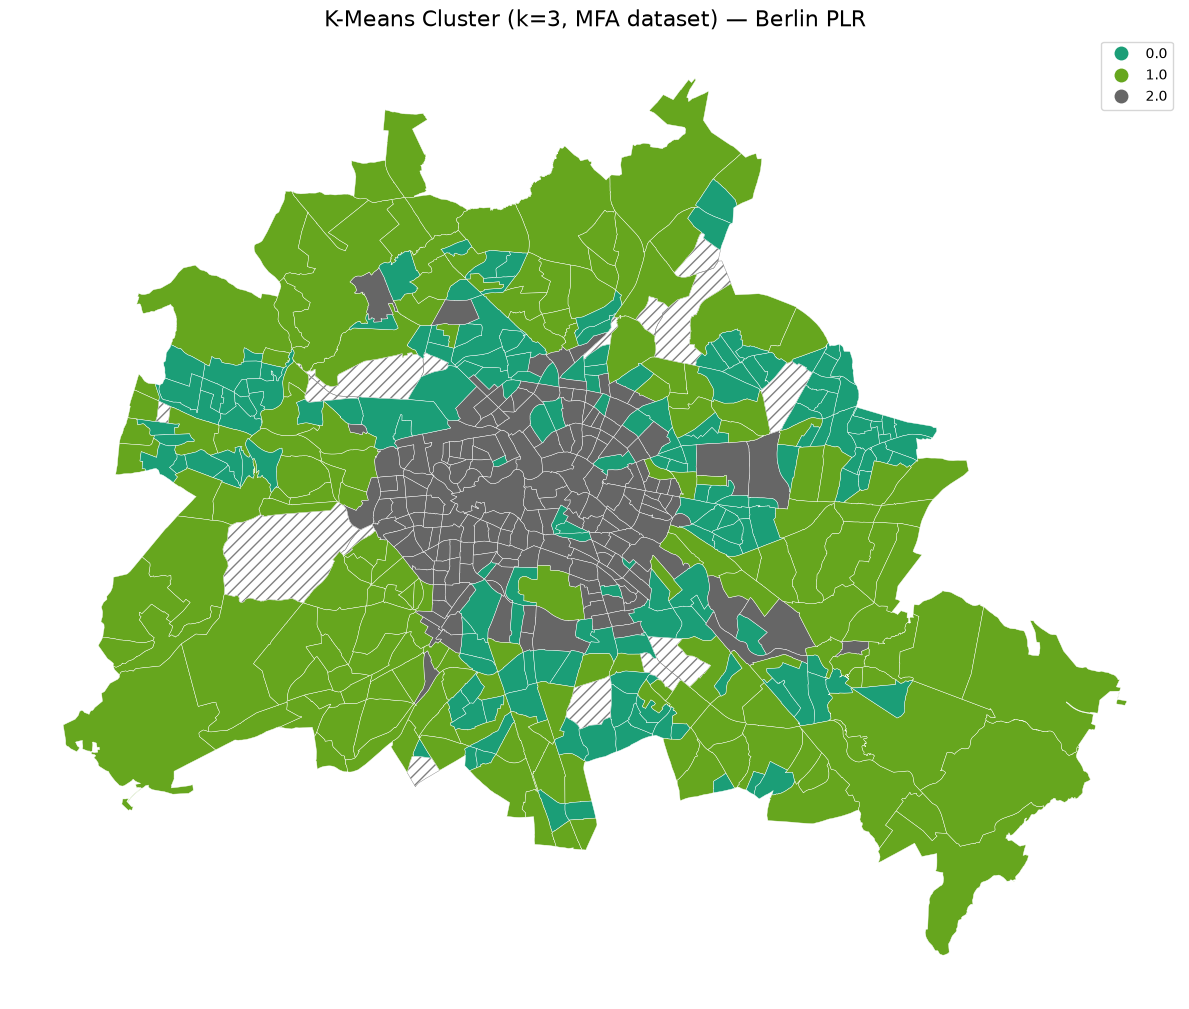

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

# mark missing PLR's
gdf[gdf["cluster_mfa"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster_mfa"].notna()].plot(
    column="cluster_mfa", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

ax.set_title(f"K-Means Cluster (k={k}, MFA dataset) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

#### Clustering: k = 4

In [ ]:
k = 4
km = KMeans(n_clusters=k, init="k-means++", n_init=50, random_state=0)
labels = km.fit_predict(X_mfa_5_coords)

# put labels back
df = df.copy()
df["cluster_mfa_4"] = labels
print(df["cluster_mfa_4"].value_counts().sort_index())

cluster_mfa_4
0     38
1    175
2    158
3    156
Name: count, dtype: int64


In [ ]:
url = ("https://gdi.berlin.de/services/wfs/lor_2021?service=WFS&version=2.0.0"
       "&request=GetFeature&typeNames=lor_2021:a_lor_plr_2021&outputFormat=application/json")
plr_geo = gpd.read_file(url)

# get plr-id's to strings with len 8
plr_geo["plr_id"] = plr_geo["plr_id"].astype(str).str.zfill(8)
df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)

gdf = plr_geo.merge(df[["plr_id_str", "cluster_mfa_4"]],
                    left_on="plr_id", right_on="plr_id_str", how="left")
print("gematcht:", gdf["cluster_mfa_4"].notna().sum(), "von", len(gdf))

gematcht: 527 von 542


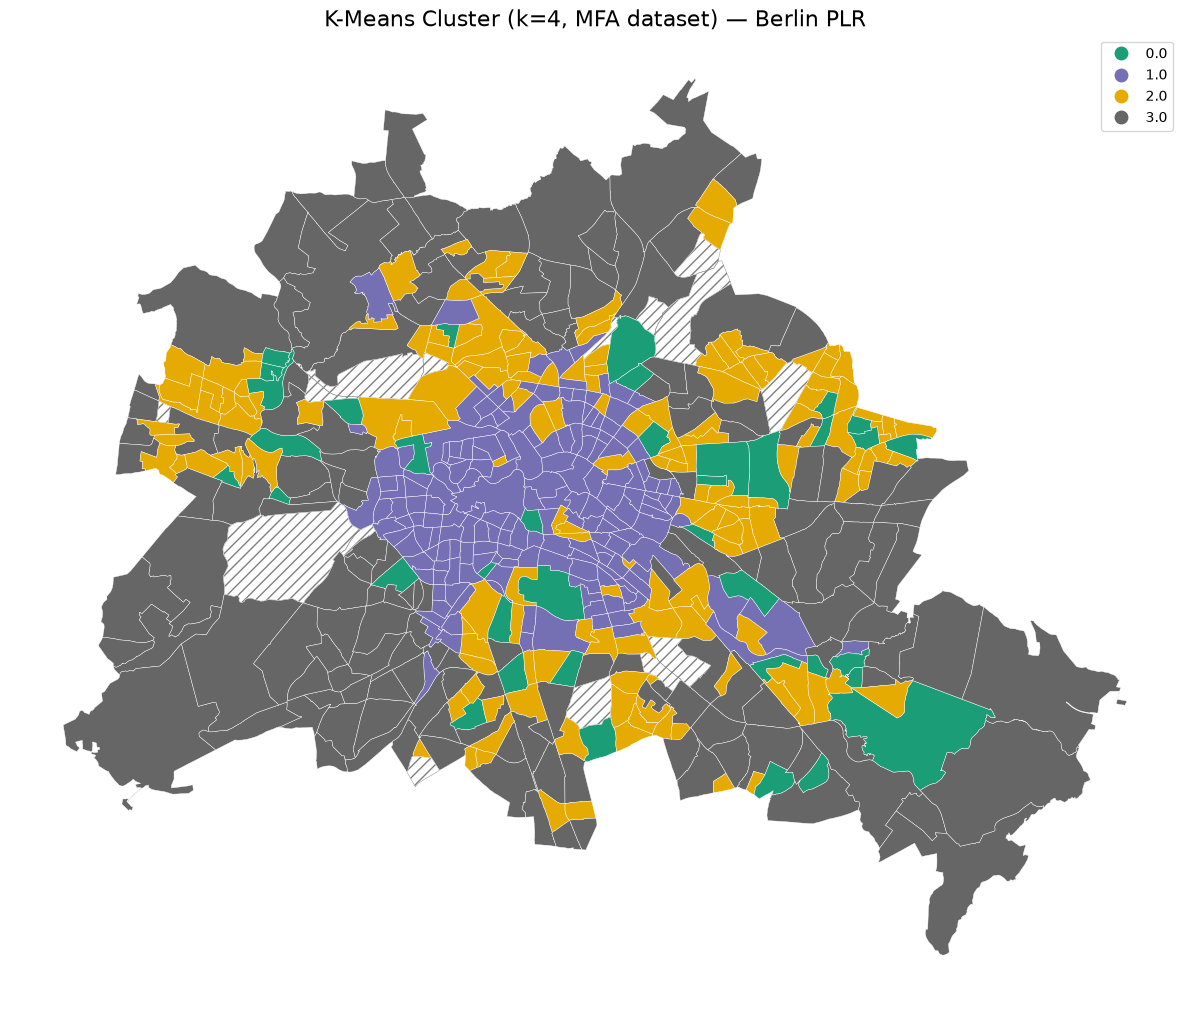

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

# mark missing PLR's
gdf[gdf["cluster_mfa_4"].isna()].plot(
    ax=ax, color="none", edgecolor="grey", hatch="///", linewidth=0.3, label="no data")

# Add clusters
gdf[gdf["cluster_mfa_4"].notna()].plot(
    column="cluster_mfa_4", categorical=True, legend=True,
    cmap="Dark2", edgecolor="white", linewidth=0.3, ax=ax)

ax.set_title(f"K-Means Cluster (k={k}, MFA dataset) — Berlin PLR", fontsize=16)
ax.axis("off"); plt.tight_layout(); plt.show()

### Comparison of bw and MFA Clusterings: 3 Clusters

In [ ]:
# compare
print("bw :", df["cluster_bw"].value_counts().sort_index().tolist())
print("mfa:", df["cluster_mfa"].value_counts().sort_index().tolist())
print("\nCrosstab:")
print(pd.crosstab(df["cluster_bw"], df["cluster_mfa"]))
print("\nARI:", round(adjusted_rand_score(df["cluster_bw"], df["cluster_mfa"]), 3))

bw : [163, 153, 211]
mfa: [175, 170, 182]

Crosstab:
cluster_mfa    0    1    2
cluster_bw                
0              6  154    3
1            147    5    1
2             22   11  178

ARI: 0.743


The ARI is at 0.74, meaning that the clusterings on the block-weighted and the MFA dataset are largely similar. Let's look at the clustering maps side by side.

In [ ]:
def align_labels(ref, other):
    cm = confusion_matrix(ref, other)
    row, col = linear_sum_assignment(-cm)
    mapping = {o: r for r, o in zip(row, col)}
    return np.array([mapping[o] for o in other])

df["cluster_mfa_aligned"] = align_labels(
    df["cluster_bw"].astype(int), df["cluster_mfa"].astype(int))

df["plr_id_str"] = df["plr_id"].astype(str).str.zfill(8)
gdf = plr_geo.merge(
    df[["plr_id_str", "cluster_bw", "cluster_mfa_aligned"]],   # aligned!
    left_on="plr_id", right_on="plr_id_str", how="left")

print([c for c in gdf.columns if "cluster" in c.lower()])   # cluster_mfa_aligned muss dabei sein  # sind die Nummern jetzt angeglichen?

['cluster_bw', 'cluster_mfa_aligned']


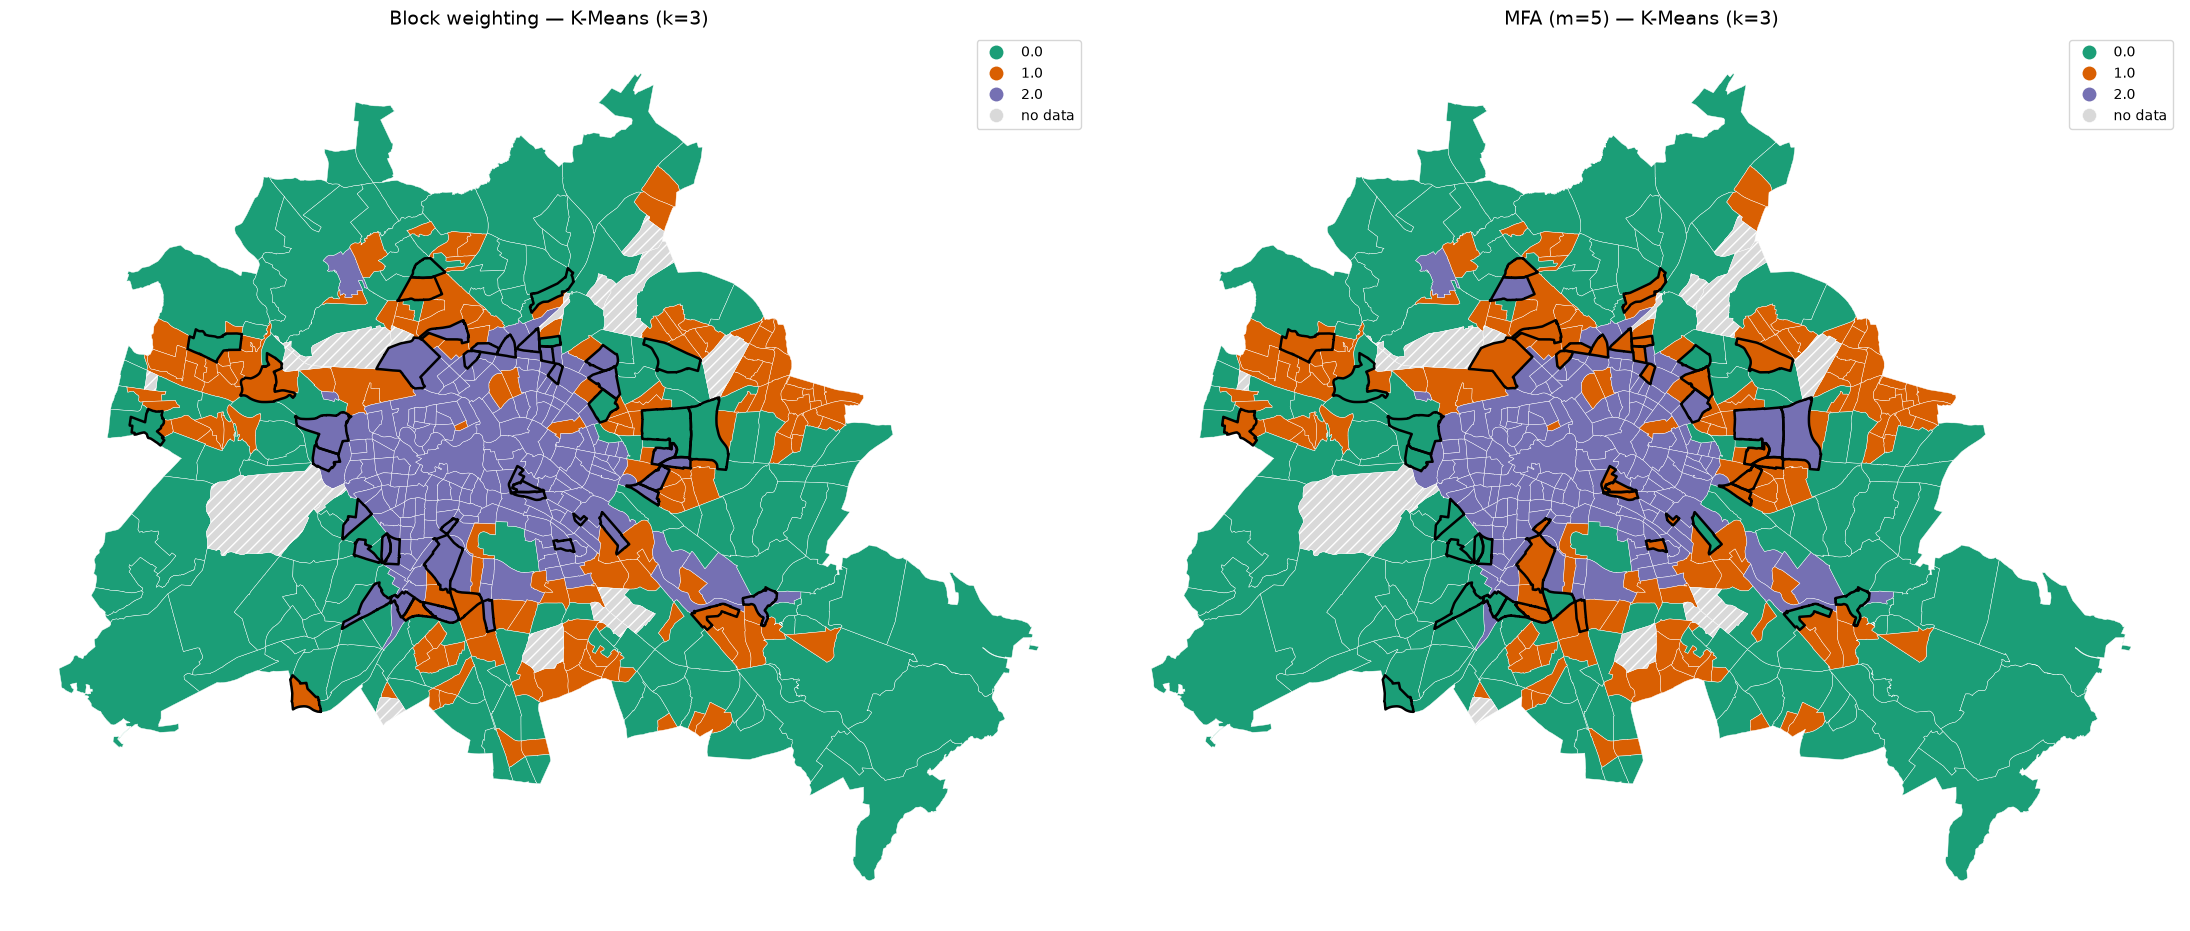

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#1b9e77", "#d95f02", "#7570b3"])

# include changed column
both = gdf["cluster_bw"].notna() & gdf["cluster_mfa_aligned"].notna()
gdf["changed"] = both & (gdf["cluster_bw"] != gdf["cluster_mfa_aligned"])

fig, axes = plt.subplots(1, 2, figsize=(22, 12))
for ax, col, title in zip(
        axes,
        ["cluster_bw", "cluster_mfa_aligned"],
        ["Block weighting", "MFA (m=5)"]):
    # 1. cluster coloring
    gdf.plot(column=col, categorical=True, legend=True, cmap=cmap,
             edgecolor="white", linewidth=0.3,
             missing_kwds={"color": "#d9d9d9", "hatch": "///", "label": "no data"},
             ax=ax)
    # 2. switched PLR get a thick border
    gdf[gdf["changed"]].plot(ax=ax, facecolor="none",
                             edgecolor="black", linewidth=1.8)
    ax.set_title(f"{title} — K-Means (k=3)", fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# real presence in both sets 
both_present = gdf["cluster_bw"].notna() & gdf["cluster_mfa_aligned"].notna()
gdf["changed"] = both_present & (gdf["cluster_bw"] != gdf["cluster_mfa_aligned"])

print("Switched PLRs:", int(gdf["changed"].sum()))          
print("NA-PLR:", int((~both_present).sum()))                  # count NA's seperately 

Switched PLRs: 48
NA-PLR: 15


48 PLRs get assigned different clusters in the MFA-based clustering compared to the block-weighted clustering. We can narrow down which these are:  

In [ ]:
print("\nMovement of Switch (bw -> mfa):")
print(out.groupby(["bw", "mfa"]).size().rename("n"))

print("\nAffected Bezirk:")
print(out["bez"].value_counts())


Movement of Switch (bw -> mfa):
bw  mfa
2   0      11
    1      22
Name: n, dtype: int64

Affected Bezirk:
bez
04 - Charlottenburg-Wilmersdorf    6
03 - Pankow                        5
01 - Mitte                         4
11 - Lichtenberg                   4
06 - Steglitz-Zehlendorf           3
02 - Friedrichshain-Kreuzberg      3
07 - Tempelhof-Schöneberg          3
09 - Treptow-Köpenick              2
08 - Neukölln                      2
12 - Reinickendorf                 1
Name: count, dtype: int64


Recall that the two approaches produce highly consistent clusterings (ARI = 0.74), with ~91% of PLRs (479/527) assigned to the same group under both methods.This confirms that the three-way core/transition/periphery structure is robust and largely independent of the balancing method.

The 48 divergent PLRs follow a clear pattern. The dominant movements are out of the core under MFA: 22 PLRs shift from core to the clusters that are located outwards (33 of 48 total). In other words, MFA produces a smaller core than block weighting. 

This pattern could reflect the different treatment of the real-estate dimension. Under block weighting, all three dimensions contribute equally, so high land values pull these PLRs into the core. Under MFA, the real-estate dimension is down-weighted to ~21%, so PLRs whose core membership rests mainly on high property values fall out of the core.

In [ ]:
# specific PLR that switch from core cluster 2 to other clusters in MFA clustering
# only real switches
both = df["cluster_bw"].notna() & df["cluster_mfa_aligned"].notna()
switched = df[both & (df["cluster_bw"] != df["cluster_mfa_aligned"])].copy()

# nur die, die aus dem Kern (Cluster 2) herausfallen
out = (switched[switched["cluster_bw"] == 2]
       [["plr_id", "plr_name", "bez", "cluster_bw", "cluster_mfa_aligned"]]
       .rename(columns={"cluster_bw": "bw", "cluster_mfa_aligned": "mfa"})
       .astype({"bw": int, "mfa": int})
       .sort_values(["mfa", "bez", "plr_name"]))   # nach Ziel-Cluster gruppiert

print(f"{len(out)} PLR move out of Cluster 2:\n")
print(out.to_string(index=False))

33 PLR move out of Cluster 2:

  plr_id                     plr_name                             bez  bw  mfa
03500933                   Weißer See                     03 - Pankow   2    0
04400834                Binger Straße 04 - Charlottenburg-Wilmersdorf   2    0
04200308              Branitzer Platz 04 - Charlottenburg-Wilmersdorf   2    0
04400832                Breite Straße 04 - Charlottenburg-Wilmersdorf   2    0
04400727            Flinsberger Platz 04 - Charlottenburg-Wilmersdorf   2    0
04200310                 Fürstenplatz 04 - Charlottenburg-Wilmersdorf   2    0
04400835            Rüdesheimer Platz 04 - Charlottenburg-Wilmersdorf   2    0
06300629           Botanischer Garten        06 - Steglitz-Zehlendorf   2    0
06100207                 Mittelstraße        06 - Steglitz-Zehlendorf   2    0
09501939                Bahnhofstraße           09 - Treptow-Köpenick   2    0
09100202             Plänterwald West           09 - Treptow-Köpenick   2    0
01400937          Afr

The two balancing approaches produce highly consistent clusterings (ARI = 0.74), with ~91% of PLRs (479/527) assigned to the same group under both methods. This confirms that the three-way core/transition/periphery structure is robust and largely independent of the balancing method.
The 48 divergent PLRs follow a clear pattern. The dominant movements are out of the core under MFA: 22 PLRs shift from core to transition and 11 from core to periphery (33 of 48 total). In other words, MFA produces a smaller core than block weighting. The affected PLRs are concentrated in districts with expensive but socially mixed edges — Pankow (8), Charlottenburg-Wilmersdorf (6), Lichtenberg (6), Steglitz-Zehlendorf (5), and Mitte (4).
This pattern reflects the different treatment of the real-estate dimension. Under block weighting, all three dimensions contribute equally, so high land values (the core averages a BRW of ~2950 vs. ~700–800 elsewhere) pull these PLRs into the core. Under MFA, the real-estate dimension is down-weighted to ~21%, so PLRs whose core membership rests mainly on high property values fall out of the core.
Since rising and elevated real-estate values are a central gentrification indicator, this supports block weighting as the primary method: it keeps the real-estate dimension on equal footing rather than marginalising it, and its clusters remain directly interpretable in the original variables. MFA serves as a robustness check, and its broad agreement confirms that the cluster structure is not an artefact of the weighting choice.

Do the two clusterings differ in cluster stability? Let's take a look.

In [ ]:
# --- Question 2: MFA (best m) vs. block weighting ---
print("\nMethod comparison (stability, k=3):")
mean_mfa, sd_mfa = subsample_stability(X_mfa_5_coords.iloc[:, :5], k=3)
mean_bw,  sd_bw  = subsample_stability(X_weighted, k=3)
print(f"  MFA (m=5):       {mean_mfa:.3f}  (±{sd_mfa:.3f})")
print(f"  Block weighting: {mean_bw:.3f}  (±{sd_bw:.3f})")


Method comparison (stability, k=3):
  MFA (m=5):       0.975  (±0.014)
  Block weighting: 0.945  (±0.026)


The stability is slightly higher for the MFA-based clustering, but still very high for the block-weighted clusters. 

### Comparison of bw and MFA Clusterings: 4 Clusters

In [ ]:
# compare
print("bw :", df["cluster_bw_4"].value_counts().sort_index().tolist())
print("mfa:", df["cluster_mfa_4"].value_counts().sort_index().tolist())
print("\nCrosstab:")
print(pd.crosstab(df["cluster_bw_4"], df["cluster_mfa"]))
print("\nARI:", round(adjusted_rand_score(df["cluster_bw_4"], df["cluster_mfa"]), 3))

bw : [150, 90, 145, 142]
mfa: [38, 175, 158, 156]

Crosstab:
cluster_mfa     0    1    2
cluster_bw_4               
0               6  144    0
1               1   16   73
2             138    6    1
3              30    4  108

ARI: 0.583


At k=4 the two methods diverge substantially (ARI = 0.53, down from 0.74 at k=3). The block-weighting core split — established city (cluster 1) vs. cheaper dense kieze (cluster 3) — is not reproduced by MFA: it assigns 67 and 107 of these PLRs respectively to the same MFA cluster, treating them as one group. Instead, MFA's fourth cluster is a small (n=38), spatially scattered residual drawn from all block-weighting clusters. This confirms that the interpretable fourth cluster is specific to block weighting and arises from the real-estate value gradient, which MFA down-weights.

## 6) Final Validation & Decision

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# =========================================================
# 1. OVERALL stability: how robust is the whole k=4 solution?
#    (subsampling + Adjusted Rand Index)
# =========================================================
def subsample_stability(X, k=4, n_runs=300, frac=0.8, seed=0):
    rng = np.random.RandomState(seed) #random generator with a fixed seed → reproducible subsamples.
    Xv = X.values if hasattr(X, "values") else X #DataFrame → NumPy array if needed (faster)
    base = KMeans(k, n_init=10, random_state=0).fit_predict(Xv) #Reference clustering on all the data. base = 527 labels.
    aris = [] #list for each runs ari value 
    for _ in range(n_runs): #repeats run n times
        idx = rng.choice(len(Xv), int(frac * len(Xv)), replace=False) #Draw 80% of the rows at random, without replacement. idx = the rows in this subsample.
        sub = KMeans(k, n_init=10, random_state=0).fit_predict(Xv[idx]) #Re-cluster only those 80%. sub = their labels.
        aris.append(adjusted_rand_score(base[idx], sub)) #Compare: base[idx] = reference labels for the same rows, sub = the new labels. ARI stored (how much the labels agree)
    return np.mean(aris), np.std(aris) #Return the mean (= stability) and the spread.

m, s = subsample_stability(X_weighted, k=4) #calling function and print result
print(f"1) Overall stability (k=4):  ARI = {m:.3f} (±{s:.3f})")

# =========================================================
# 2. SEED stability: does the solution depend on the random start? 
# =========================================================
runs = [KMeans(4, n_init=10, random_state=sd).fit_predict(X_weighted) for sd in range(20)] #Cluster 10x on the same full data, but with 10 different random_state values. Test: does the result change when only the random start changes?
seed_ari = np.mean([adjusted_rand_score(runs[0], r) for r in runs[1:]]) #Compare run 0 against runs 1–19 (ARI each), average them. High = seed-independent.
print(f"2) Seed stability (k=4):     ARI = {seed_ari:.3f}") #print

# =========================================================
# 3. CLUSTER-WISE stability: which of the 4 clusters is robust?
#    (bootstrap/subsample + Jaccard, following Hennig 2007)
# =========================================================
def clusterwise_stability(X, k=4, n_runs=300, frac=0.8, seed=0): #same setup as above
    rng = np.random.RandomState(seed)
    Xv = X.values if hasattr(X, "values") else X
    n = len(Xv)
    base = KMeans(k, n_init=10, random_state=0).fit_predict(Xv) #Reference clustering, plus for each cluster the set of its members (as row indices). 
    base_sets = {c: set(np.where(base == c)[0]) for c in range(k)} #Sets are needed for the intersection/union in the Jaccard calculation.
    jaccard = {c: [] for c in range(k)} #one list per cluster
    for _ in range(n_runs): 
        idx = rng.choice(n, int(frac * n), replace=False) #Draw a random subsample: int(frac*n) = 421 row positions out of n=527, without replacement (no duplicates). idx = the rows included in this run.
        idx_set = set(idx) #The same indices as a set — needed below to restrict the reference clusters to only the rows that are in this subsample
        sub = KMeans(k, n_init=10, random_state=0).fit_predict(Xv[idx]) #Re-cluster only the 421 subsample rows. sub = the new labels, but only for the subsample rows, and with possibly different cluster numbers than base.
        sub_sets = {c: set(idx[sub == c]) for c in range(k)} #For each subsample cluster c, the set of its members — as original row numbers. 
        #idx[sub == c] translates the subsample-internal positions back into the original row indices, so they can be compared with base_sets.
        for c in range(k): #Checking each reference cluster (from the full-data clustering) one at a time — how well is it reproduced in this subsample?
            ref = base_sets[c] & idx_set #The reference members of cluster c, restricted to those present in the subsample (& = set intersection)
            if not ref: #If ref is empty (no members landed in the subsample), skip to the next cluster — avoids dividing by zero. Rare, but a safety net.
                continue
            best = max(len(ref & sset) / len(ref | sset) for sset in sub_sets.values()) #Jaccard coefficient. For each subsample cluster sset, compute len(ref & sset) / len(ref | sset) = (shared members) / (all members of both combined) = overlap from 0 to 1. 
            #max(...) takes the best match — the subsample cluster most similar to reference cluster c. Using the best match (rather than comparing cluster c to cluster c) handles the fact that cluster numbering changes between runs.
            jaccard[c].append(best) #Store that best Jaccard value in cluster c's list.
    return {c: (np.mean(v), np.std(v)) for c, v in jaccard.items()} #After all runs: for each cluster, return the mean (= its stability index) and the spread of its Jaccard values. 
#A high mean = the cluster is reliably recovered in almost every subsample.

print("3) Cluster-wise stability (Jaccard):")
res = clusterwise_stability(X_weighted, k=4)
for c, (mj, sj) in sorted(res.items()):
    print(f"     Cluster {c}: {mj:.3f} (±{sj:.3f})") 
    #Print each cluster's stability: mj = mean Jaccard, sj = its spread. sorted(res.items()) just orders the output by cluster number.
    #The core idea:for each real cluster, repeatedly measure how strongly it reappears in a random 80% subsample 
    # (via Jaccard overlap with the most similar subsample cluster), then average — a stable cluster keeps reappearing intact, an unstable one dissolves into different groupings.

1) Overall stability (k=4):  ARI = 0.831 (±0.141)
2) Seed stability (k=4):     ARI = 0.986
3) Cluster-wise stability (Jaccard):
     Cluster 0: 0.797 (±0.225)
     Cluster 1: 0.919 (±0.063)
     Cluster 2: 0.875 (±0.100)
     Cluster 3: 0.843 (±0.167)


Cluster stability for the k=4 solution was assessed over 300 subsamples (80%), using the Adjusted Rand Index for the overall and seed stability and the cluster-wise Jaccard criterion (Hennig 2007, https://www.homepages.ucl.ac.uk/~ucakche/papers/clusta.pdf). The solution is highly seed-independent (ARI 0.986) and overall stable (ARI 0.831). Three of the four clusters are highly stable — Cluster 1 (0.92), Cluster 2 (0.88), and Cluster 3 (0.84) — confirming that the split of the dense core into two types (the reason for choosing k=4) is robust. The least sharply bounded cluster is Cluster 0 (0.80 ± 0.23), consistent with its nature as a transitional zone with gradual edges.

**Decision:** We use the k=4 solution with block weighting. Going from three to four clusters splits the dense core into two clear types. This split is stable (Jaccard 0.84–0.92) and spatially coherent, so the small drop in overall stability (0.83 vs. 0.95) is worth the added detail. We chose block weighting over MFA because it treats all three dimensions equally and keeps the real-estate dimension fully weighted. MFA down-weights real estate to ~21% and fails to reproduce this split, producing a scattered residual cluster instead.

In [36]:
out = (df[["plr_id", "cluster_bw", "cluster_bw_4"]]
       .rename(columns={"cluster_bw": "cluster_3k",
                        "cluster_bw_4": "cluster_4k"}))

out.to_csv("../../data/Module_1/cluster_assignments.csv", index=False)
print(out.head())
print(f"\nsaved {len(out)} rows")

     plr_id  cluster_3k  cluster_4k
0  01100101           2           1
1  01100102           2           1
2  01100103           2           1
3  01100104           2           1
4  01100205           2           1

saved 527 rows
